In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import matplotlib.pyplot as plt

In [47]:
df = pd.read_csv("processed_dataset_new_.csv")
df.head()

,PatientID,Age,Gender,BMI,BloodPressure,GlucoseLevel,Insulin,SkinThickness,DiabetesPedigreeFunction,PhysicalActivity,Smoking,Alcohol_Intake,FamilyHistory,Outcome
0,1,69,1,34.6,61.0,89.0,87.0,30.0,1.498,2,0,3.0,0,0
1,2,32,0,21.8,95.0,115.0,102.0,27.0,0.672,1,1,3.0,1,0
2,3,78,0,31.7,64.0,70.0,75.0,13.0,0.980,2,1,1.0,1,0
3,4,38,0,21.7,83.0,135.0,158.0,26.0,1.239,2,1,1.0,0,1
4,5,41,1,24.3,71.0,131.0,90.0,12.0,0.425,1,0,3.0,0,1


In [48]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [52]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [53]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [54]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n🔹 {model_name} Performance:")
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [55]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")


🔹 Logistic Regression Performance:
Accuracy: 0.895
Precision: 0.8909090909090909
Recall: 0.9158878504672897
F1 Score: 0.9032258064516129

Confusion Matrix:
[[81 12]
 [ 9 98]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89        93
           1       0.89      0.92      0.90       107

    accuracy                           0.90       200
   macro avg       0.90      0.89      0.89       200
weighted avg       0.90      0.90      0.89       200



In [56]:
evaluate_model(y_test, y_pred_knn, "KNN")


🔹 KNN Performance:
Accuracy: 0.765
Precision: 0.8
Recall: 0.7476635514018691
F1 Score: 0.7729468599033816

Confusion Matrix:
[[73 20]
 [27 80]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.78      0.76        93
           1       0.80      0.75      0.77       107

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.77       200



In [57]:
evaluate_model(y_test, y_pred_svm, "SVM")


🔹 SVM Performance:
Accuracy: 0.89
Precision: 0.8761061946902655
Recall: 0.9252336448598131
F1 Score: 0.9

Confusion Matrix:
[[79 14]
 [ 8 99]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88        93
           1       0.88      0.93      0.90       107

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



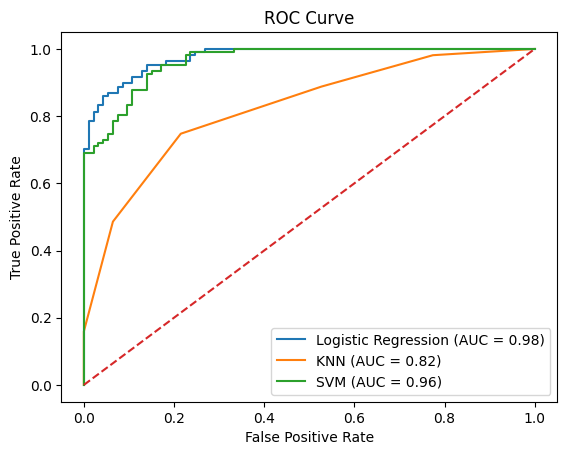

In [58]:
def plot_roc(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.figure()

plot_roc(lr, X_test, y_test, "Logistic Regression")
plot_roc(knn, X_test, y_test, "KNN")
plot_roc(svm, X_test, y_test, "SVM")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

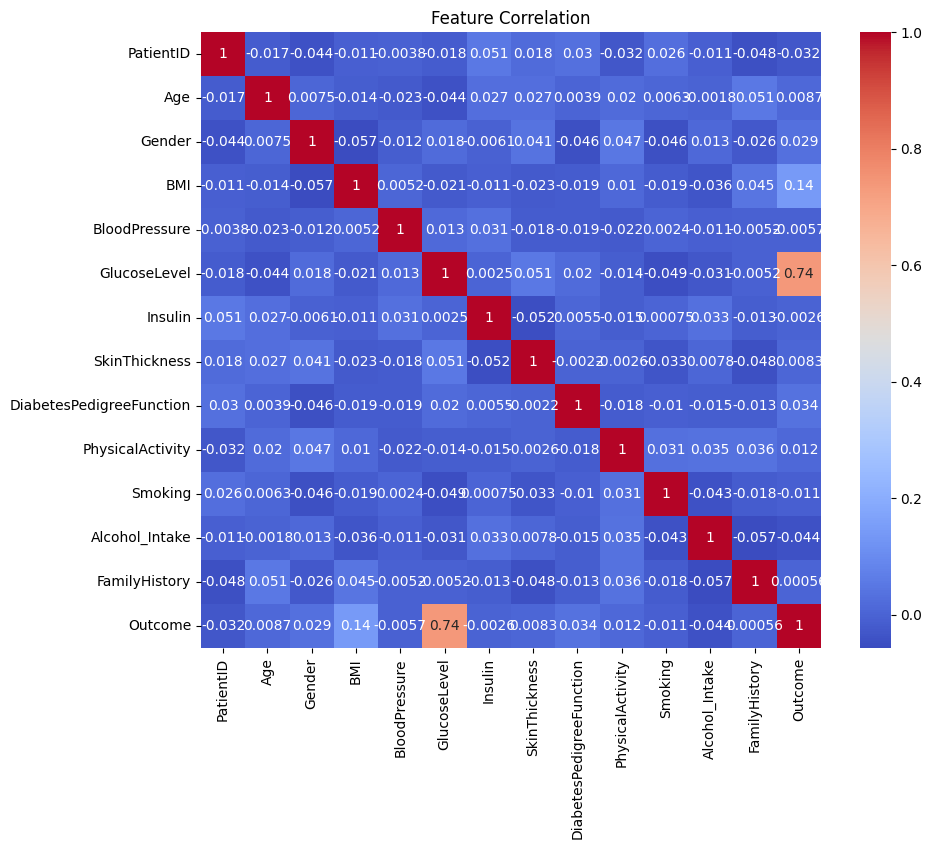

In [65]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()